In [1]:
import sys
sys.path.insert(0, "/global/u1/p/prakharb/desilike")
import sys
sys.path.insert(0, "/global/u1/p/prakharb/cosmoprimo")
sys.path.insert(0,"/global/u1/p/prakharb/FOLPSpipe/folps")
import desilike, inspect
print(inspect.getfile(desilike))
import cosmoprimo, inspect
print(inspect.getfile(cosmoprimo))
import folps, inspect
print(inspect.getfile(folps))

/global/u1/p/prakharb/desilike/desilike/__init__.py
/global/u1/p/prakharb/cosmoprimo/cosmoprimo/__init__.py
✅ Using NumPy with CPU.
/global/u1/p/prakharb/FOLPSpipe/folps/folps.py


In [2]:
import sys, os, shutil
import time
import emcee
import numpy as np
from schwimmbad import MPIPool

from datetime import datetime

from mike_data_tools import *

In [3]:
derived_params = ['sigma8', 'Omega_m']

k_min=0.02
k_max=0.201
k_max_b0 = 0.14
k_max_b2 = 0.10

isP0, isP2, isP4 =True, True, False
isB000, isB202 = False, False

Vol=1

tracer='LRG'
z_str='z0.800'
z_evaluation=0.8

path_fits='chains/'

now = datetime.now()
tiempo=now.strftime("%m-%d-%Y-%H%M")

name=f"c_FolpsD__{tracer}_z{z_evaluation:.3f}_Pkmax-{k_max:.3f}_B000kmax-{k_max_b0:.3f}_B202kmax-{k_max_b2:.3f}_bsfree"


chains_filename = path_fits+name+".h5"
copy_filename = path_fits+name+".py"
print(chains_filename)
    

# +
k_data_2nd,pkl0_2nd_all,pkl2_2nd_all,a,B000_2nd_all,B202_2nd_all = ExtractDataAbacusSummit(tracer,z_str,
                                                                                           subtract_shot=True)

Pk_0_2nd = np.mean(pkl0_2nd_all,axis = 0)
Pk_2_2nd = np.mean(pkl2_2nd_all,axis = 0)
B000_2nd = np.mean(B000_2nd_all,axis = 0)
B202_2nd = np.mean(B202_2nd_all,axis = 0)


chains/c_FolpsD__LRG_z0.800_Pkmax-0.201_B000kmax-0.140_B202kmax-0.100_bsfree.h5


In [4]:
# Read covariance

k_eff_all,pkl0ezmocks,pkl2ezmocks,pkl4ezmocks,B000ezmocks,B202ezmocks = ExtractDataEZmock(tracer,z_str)
k_cov_all, mean_ezmocks_all, cov_array_all = covariance(k_eff_all,pkl0ezmocks,pkl2ezmocks,pkl4ezmocks,B000ezmocks,B202ezmocks, Nscaling = Vol)



pole_selection=[isP0, isP2, isP4,isB000, isB202]
print(pole_selection)

kmin_pk=0.02; kmax_pk=k_max
kmin_bk=0.02; 
ranges=[[kmin_pk,kmax_pk],[kmin_pk,kmax_pk],[kmin_pk,kmax_pk],[kmin_bk,k_max_b0],[kmin_bk,k_max_b2]]

mask=pole_k_selection(k_cov_all,pole_selection,ranges)
#print(mask.shape)
#print(mask)
k_cov=k_cov_all[mask]

#k_cov.shape
k_points_pk = np.where((kmin_pk < k_data_2nd) & (k_data_2nd < kmax_pk)  & isP0)
k_points_b0 = np.where((kmin_bk < k_data_2nd) & (k_data_2nd < k_max_b0) & isB000)
k_points_b2 = np.where((kmin_bk < k_data_2nd) & (k_data_2nd < k_max_b2) & isB202)

data = np.concatenate((Pk_0_2nd[k_points_pk],Pk_2_2nd[k_points_pk],
                       B000_2nd[k_points_b0],B202_2nd[k_points_b2]))
kr_pk=k_data_2nd[k_points_pk]
kr_b0=k_data_2nd[k_points_b0]
kr_b2=k_data_2nd[k_points_b2]

numberofpk0points=len(Pk_0_2nd[k_points_pk])
numberofbk0points=len(B000_2nd[k_points_b0])
numberofbk2points=len(B202_2nd[k_points_b2])

cov_array=cov_array_all[np.ix_(mask, mask)]
totsim = 2000 #number of sims
n_data = len(data)
Hartlap = (totsim - 1.) / (totsim - n_data - 2.)
Hartlap
cov_arr = cov_array * Hartlap
cov_inv_arr = np.linalg.inv(cov_arr)


[True, True, False, False, False]


In [7]:
cov_arr.shape

(74, 74)

In [5]:
# Save data and inv covariance matrix to a file
np.save("data.npy",data)
np.save("cov.npy",cov_arr)

In [ ]:
#Load data and covariance matrix
data = np.load("data.npy")
cov_arr = np.load("cov.npy")


In [2]:
from desilike.theories.galaxy_clustering import FixedPowerSpectrumTemplate, LPTVelocileptorsTracerPowerSpectrumMultipoles, KaiserTracerPowerSpectrumMultipoles, DirectPowerSpectrumTemplate,FixedPowerSpectrumTemplate
from desilike.theories.galaxy_clustering.full_shape import  FOLPSv2TracerPowerSpectrumMultipoles,FOLPSAXTracerPowerSpectrumMultipoles, PyBirdTracerPowerSpectrumMultipoles
from desilike.observables import ObservableCovariance
from desilike.observables.galaxy_clustering import TracerPowerSpectrumMultipolesObservable
from desilike.likelihoods import ObservablesGaussianLikelihood
from desilike.profilers import MinuitProfiler
from desilike.emulators import Emulator, EmulatedCalculator, TaylorEmulatorEngine
from desilike import setup_logging

setup_logging()

template = DirectPowerSpectrumTemplate(z=0.8)
theory = FOLPSv2TracerPowerSpectrumMultipoles(template=template, tracer='LRG',freedom='max',kernels='fk',prior_basis='standard',damping='lor',ells=[0,2])
# emulator=EmulatedCalculator.load("_tests/folpsv2_emulator_LRG.npy")
# observables = TracerPowerSpectrumMultipolesObservable(data=data,covariance=cov_arr,ells=[0,2],k=kr_pk,theory=theory)
# likelihood = ObservablesGaussianLikelihood(observables=[observables])
# likelihood()

: 

In [19]:
theory.pt.z

Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy


array(0.8)

/global/u1/p/prakharb/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy
[000047.44] [0/1] 08-05 15:12  Emulator                  INFO     Varied parameters: ['h', 'omega_cdm', 'omega_b', 'logA'].
[000047.45] [0/1] 08-05 15:12  Emulator                  INFO     Found varying ['sigma8', 'fsigma8', 'jac', 'kap', 'muap', 'table', 'table_now', 'scalars', 'scalars_now'] and fixed ['k', 'z', 'ells', 'wmu', 'kt'] outputs.
[000049.02] [0/1] 08-05 15:12  Differentiation           INFO     Varied parameters: ['h', 'omega_cdm', 'omega_b', 'logA'].
[000055.77] [0/1] 08-05 15:12  Differentiation           INFO     h grid is [0.6136 0.6436 0.6736 0.7036 0.7336].
[000055.81] [0/1] 08-05 15:12  Differentiation           INFO     omega_cdm grid is [0.1  0.11 0.12 0.13 0.14].
[000055.81] [0/1] 08-05 15:12  Differentiation           INFO     omega_b grid is [0.01937 0.02087 0.02237 0.02387 0.02537].
[000055.81] [0/1] 08-05 15:12  Differentiation           INFO     logA grid is [2.93639426 2.98639426

[<Figure size 600x600 with 2 Axes>,
 <Figure size 600x600 with 2 Axes>,
 <Figure size 600x600 with 2 Axes>,
 <Figure size 600x600 with 2 Axes>,
 <Figure size 600x600 with 2 Axes>,
 <Figure size 600x600 with 2 Axes>,
 <Figure size 600x600 with 2 Axes>,
 <Figure size 600x600 with 2 Axes>,
 <Figure size 600x600 with 2 Axes>]

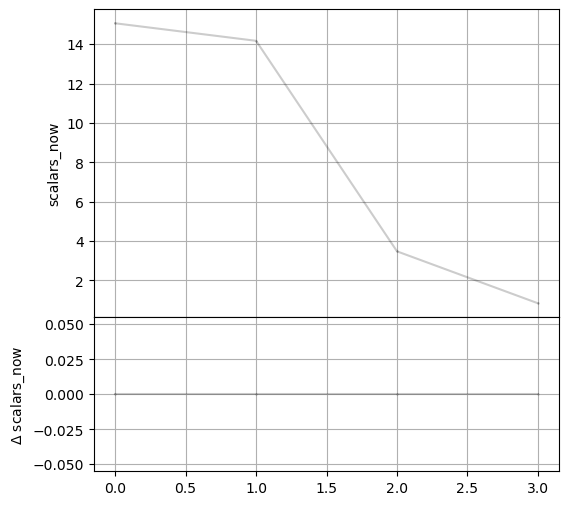

In [20]:
from desilike.emulators import Emulator
from desilike.emulators import Emulator, EmulatedCalculator, TaylorEmulatorEngine
emulator = Emulator(theory.pt, engine=TaylorEmulatorEngine(method='finite', order=4))  # order 2 except for sn0 (order 1 is enough)
emulator.set_samples()
emulator.fit()
emulator.plot(name='power')
# emulator= Emulator.load('../_tests/folpsv2_emulator.npy')

In [26]:
import os
base_dir = '_tests'
folps_emulator_fn = os.path.join(base_dir, 'folpsv2_emulator_LRG_pt.npy')
emulator.save(folps_emulator_fn)

[000555.64] [0/1] 08-05 15:21  Emulator                  INFO     Saving _tests/folpsv2_emulator_LRG_pt.npy.
[000555.65] [0/1] 08-05 15:21  BaseConfig                INFO     Saving _tests/folpsv2_emulator_LRG_pt.yaml.


In [6]:
from desilike.theories.galaxy_clustering import FixedPowerSpectrumTemplate, LPTVelocileptorsTracerPowerSpectrumMultipoles, KaiserTracerPowerSpectrumMultipoles, DirectPowerSpectrumTemplate,FixedPowerSpectrumTemplate
from desilike.theories.galaxy_clustering.full_shape import  FOLPSv2TracerPowerSpectrumMultipoles,FOLPSAXTracerPowerSpectrumMultipoles, PyBirdTracerPowerSpectrumMultipoles
from desilike.observables import ObservableCovariance
from desilike.observables.galaxy_clustering import TracerPowerSpectrumMultipolesObservable
from desilike.likelihoods import ObservablesGaussianLikelihood
from desilike.profilers import MinuitProfiler
from desilike.emulators import Emulator, EmulatedCalculator, TaylorEmulatorEngine
from desilike import setup_logging

emulator=Emulator.load('_tests/folpsv2_emulator_LRG.npy')
theory=emulator.to_calculator()
# observables = TracerPowerSpectrumMultipolesObservable(data=data,covariance=cov_arr,ells=[0,2],k=kr_pk,theory=theory)
# likelihood = ObservablesGaussianLikelihood(observables=[observables])

# params_list = ['alpha0', 'alpha2', 'alpha4', 'sn0', 'sn2']

# for param in params_list:    
#    theory.params[param].update(derived = '.marg')

[000053.44] [0/1] 08-05 14:43  Emulator                  INFO     Loading _tests/folpsv2_emulator_LRG.npy.


In [3]:
emulator_filename = '../Emulator_test/emu_-LRG1_LRG1.npy'
emulator = EmulatedCalculator.load(emulator_filename)  
theory.init.update(pt=emulator)

[000016.00] [0/1] 08-05 16:14  Emulator                  INFO     Loading ../Emulator_test/emu_-LRG1_LRG1.npy.


In [4]:
theory()

AttributeError: calculator FOLPSv2PowerSpectrumMultipoles has no attribute model; have you run any calculation already by calling this calculator or calculators that depend on it (typically, a likelihood?)

In [ ]:


from desilike.samplers import ZeusSampler, EmceeSampler

# Let's just update the observable's theory, no need to redefine the observable & likelihood
# (Internally the code will reinitialize all calculators that depend on observable)


sampler = EmceeSampler(likelihood, save_fn='_tests/chain_fs_direct_*.npy', seed=42, chains='_tests/chain_fs_direct_*.npy')
sampler.run(check={'max_eigen_gr': 0.01})

In [11]:
likelihood.all_params

ParameterCollection(['h', 'omega_cdm', 'omega_b', 'logA', 'n_s', 'tau_reio', 'm_ncdm', 'N_eff', 'w0_fld', 'wa_fld', 'Omega_k', 'sigmapar', 'sigmaper', 'b1', 'sn0', 'loglikelihood', 'logprior'])

In [69]:
a,b=theory()

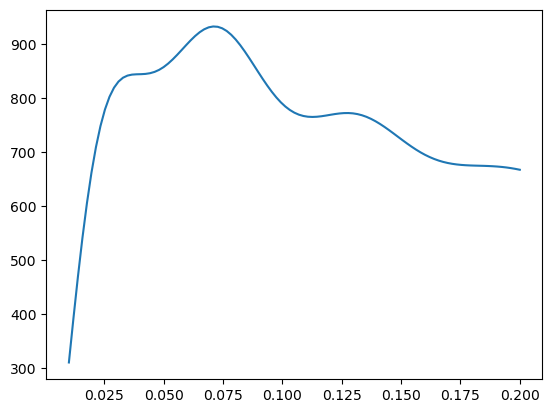

In [59]:
import matplotlib.pyplot as plt
k=theory.k
plt.plot(k,a*k,label='P0')

In [7]:
from desilike.emulators import Emulator
from desilike.emulators import Emulator, EmulatedCalculator, TaylorEmulatorEngine
emulator=Emulator.load('_tests/folpsv2_emulator_LRG.npy')

In [9]:
emulator.fit()
emulator.plot(name='power')

AttributeError: 'Emulator' object has no attribute '_samples_operations'

# Chain Plotting

In [36]:
%matplotlib inline

from desilike.samples import Chain
from desilike import setup_logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
setup_logging()

#funtion to load numpy chains
def load_chain(fi, burnin=0.3):
    from desilike.samples import Chain
    # chains = [Chain.load(ff).remove_burnin(burnin) for ff in fi]
    chains = [Chain.load(fi).remove_burnin(burnin)]
    chain = chains[0].concatenate(chains)
    print(f'chain: {chain}')
    return chain

chain_path = Path('/global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_new_folpsv2_fk_ps_0.201_Afull_true.npy')
chain = load_chain(chain_path)
samples2 = chain.to_getdist()
# chain_path = Path('/global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_klim_0-0.02-0.2_2-0.02-0.2-LRG1-GCcomb_schoneberg2024-bbn_planck2018-ns10_physical-prior_LCDM_folpsv2_new.npy')
# chain = load_chain(chain_path)
# samples3 = chain.to_getdist()

chain_path = Path('/global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_new_folpsv2_fk_ps_0.201_Afull_false.npy')
chain2 = load_chain(chain_path)
samples3 = chain2.to_getdist()

[000000.01] [0/1] 09-08 13:39  Chain                     INFO     Loading /global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_new_folpsv2_fk_ps_0.201_Afull_true.npy.
chain: Chain(shape=(6510,), params=ParameterCollection(['h', 'omega_cdm', 'omega_b', 'logA', 'b1', 'b2', 'bs', 'fweight', 'logposterior', 'n_s', 'tau_reio', 'm_ncdm', 'N_eff', 'w0_fld', 'wa_fld', 'Omega_k', 'b3', 'ct', 'X_FoG_p', 'H0', 'Omega_m', 'sigma8_m', 'loglikelihood', 'logprior', 'alpha0', 'alpha2', 'sn0', 'sn2']))
Removed no burn in
[000000.11] [0/1] 09-08 13:39  Chain                     INFO     Loading /global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_new_folpsv2_fk_ps_0.201_Afull_false.npy.
chain: Chain(shape=(14070,), params=ParameterCollection(['h', 'omega_cdm', 'omega_b', 'logA', 'b1', 'b2', 'bs', 'fweight', 'logposterior', 'n_s', 'tau_reio', 'm_ncdm', 'N_eff', 'w0_fld', 'wa_fld', 'Omega_k', 'b3', 'ct', 'X_FoG_p', 'H0', 'Omega_m', 'sigma8_m', 'loglikelihood', 'logprior', 'alph

In [2]:
chain2.choice()

{'h': 0.6868918282644423,
 'omega_cdm': 0.1260376298152201,
 'omega_b': 0.02234286485648529,
 'logA': 3.241295961506764,
 'LRG2.b1': 1.0450165832553644,
 'LRG2.b2': 5.539902369642752,
 'LRG2.bs': -0.5279683825669661,
 'LRG2.c1': 12.819523074969478,
 'LRG2.c2': -8.289044730879398,
 'LRG2.Pshot': 4453.637720388913,
 'LRG2.Bshot': 887.5935715013993,
 'LRG2.X_FoG_b': 0.39884906152533517,
 'fweight': 60.93632753452384,
 'logposterior': -12.89082428784787,
 'n_s': 0.9648999999999999,
 'tau_reio': 0.054400000000000004,
 'm_ncdm': 0.06,
 'N_eff': 3.046,
 'w0_fld': -1.0,
 'wa_fld': 0.0,
 'Omega_k': 0.0,
 'H0': 68.6891828264455,
 'Omega_m': 0.31597789834829315,
 'sigma8_m': 0.9302209434489487,
 'loglikelihood': -12.309612314311892,
 'logprior': -0.5812119735359801,
 'aweight': 1.0}

In [80]:
# default_path = Path('/global/cfs/cdirs/desi//survey/catalogs/DA2/analysis/loa-v1/LSScats/v1.1/BAO/blinded/desipipe/fits_2pt/fits_power_dampedbao_bao-qisoqap_pcs/recon_IFFT_recsym_sm30/')
# # P0 +P2 chains
# base_path= f'{default_path}/chain_QSO_GCcomb_z0.8-2.1_default_FKP_cov-thecov_sigmas-2.0-2.0_sigmapar-6.0-2.0_sigmaper-3.0-1.0_lim_0-0.02-0.30_2-0.02-0.30'   
# # P0+P2+P4 chains
# base_path2= f'{default_path}/chain_QSO_GCcomb_z0.8-2.1_default_FKP_cov-thecov_sigmas-2.0-2.0_sigmapar-6.0-2.0_sigmaper-3.0-1.0_lim_0-0.02-0.30_2-0.02-0.30_4-0.02-0.30'
# #base_path_corr = f'{default_corr_path}/chain_LRG_GCcomb_z0.8-1.1_default_FKP_cov-rascalc_sigmas-2.0-2.0_sigmapar-11.25-2.0_sigmaper-5.0-1.0_lim_0-60-150_2-60-150'
# chain_paths = []
# chain_paths2=[]

# for i in range(8):
#     chain_paths.append(f'{base_path}_{i}.npy')
#     chain_paths2.append(f'{base_path2}_{i}.npy')
chain_path = Path('/global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_folpsv2.npy')

In [81]:
chain = load_chain(chain_path)
samples2 = chain.to_getdist()
# chain2 = load_chain(chain_paths2)[::10]

[010764.41] [0/1] 08-06 21:15  Chain                     INFO     Loading /global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_folpsv2.npy.
chain: Chain(shape=(38850,), params=ParameterCollection(['h', 'omega_cdm', 'omega_b', 'logA', 'n_s', 'LRG2.b1p', 'LRG2.b2p', 'LRG2.bsp', 'LRG2.X_FoG_pp', 'fweight', 'logposterior', 'tau_reio', 'm_ncdm', 'N_eff', 'w0_fld', 'wa_fld', 'Omega_k', 'LRG2.b3p', 'LRG2.ctp', 'H0', 'Omega_m', 'sigma8_m', 'loglikelihood', 'logprior', 'LRG2.alpha0p', 'LRG2.alpha2p', 'LRG2.alpha4p', 'LRG2.sn0p', 'LRG2.sn2p']))
Removed no burn in


Removed no burn in
Removed no burn in


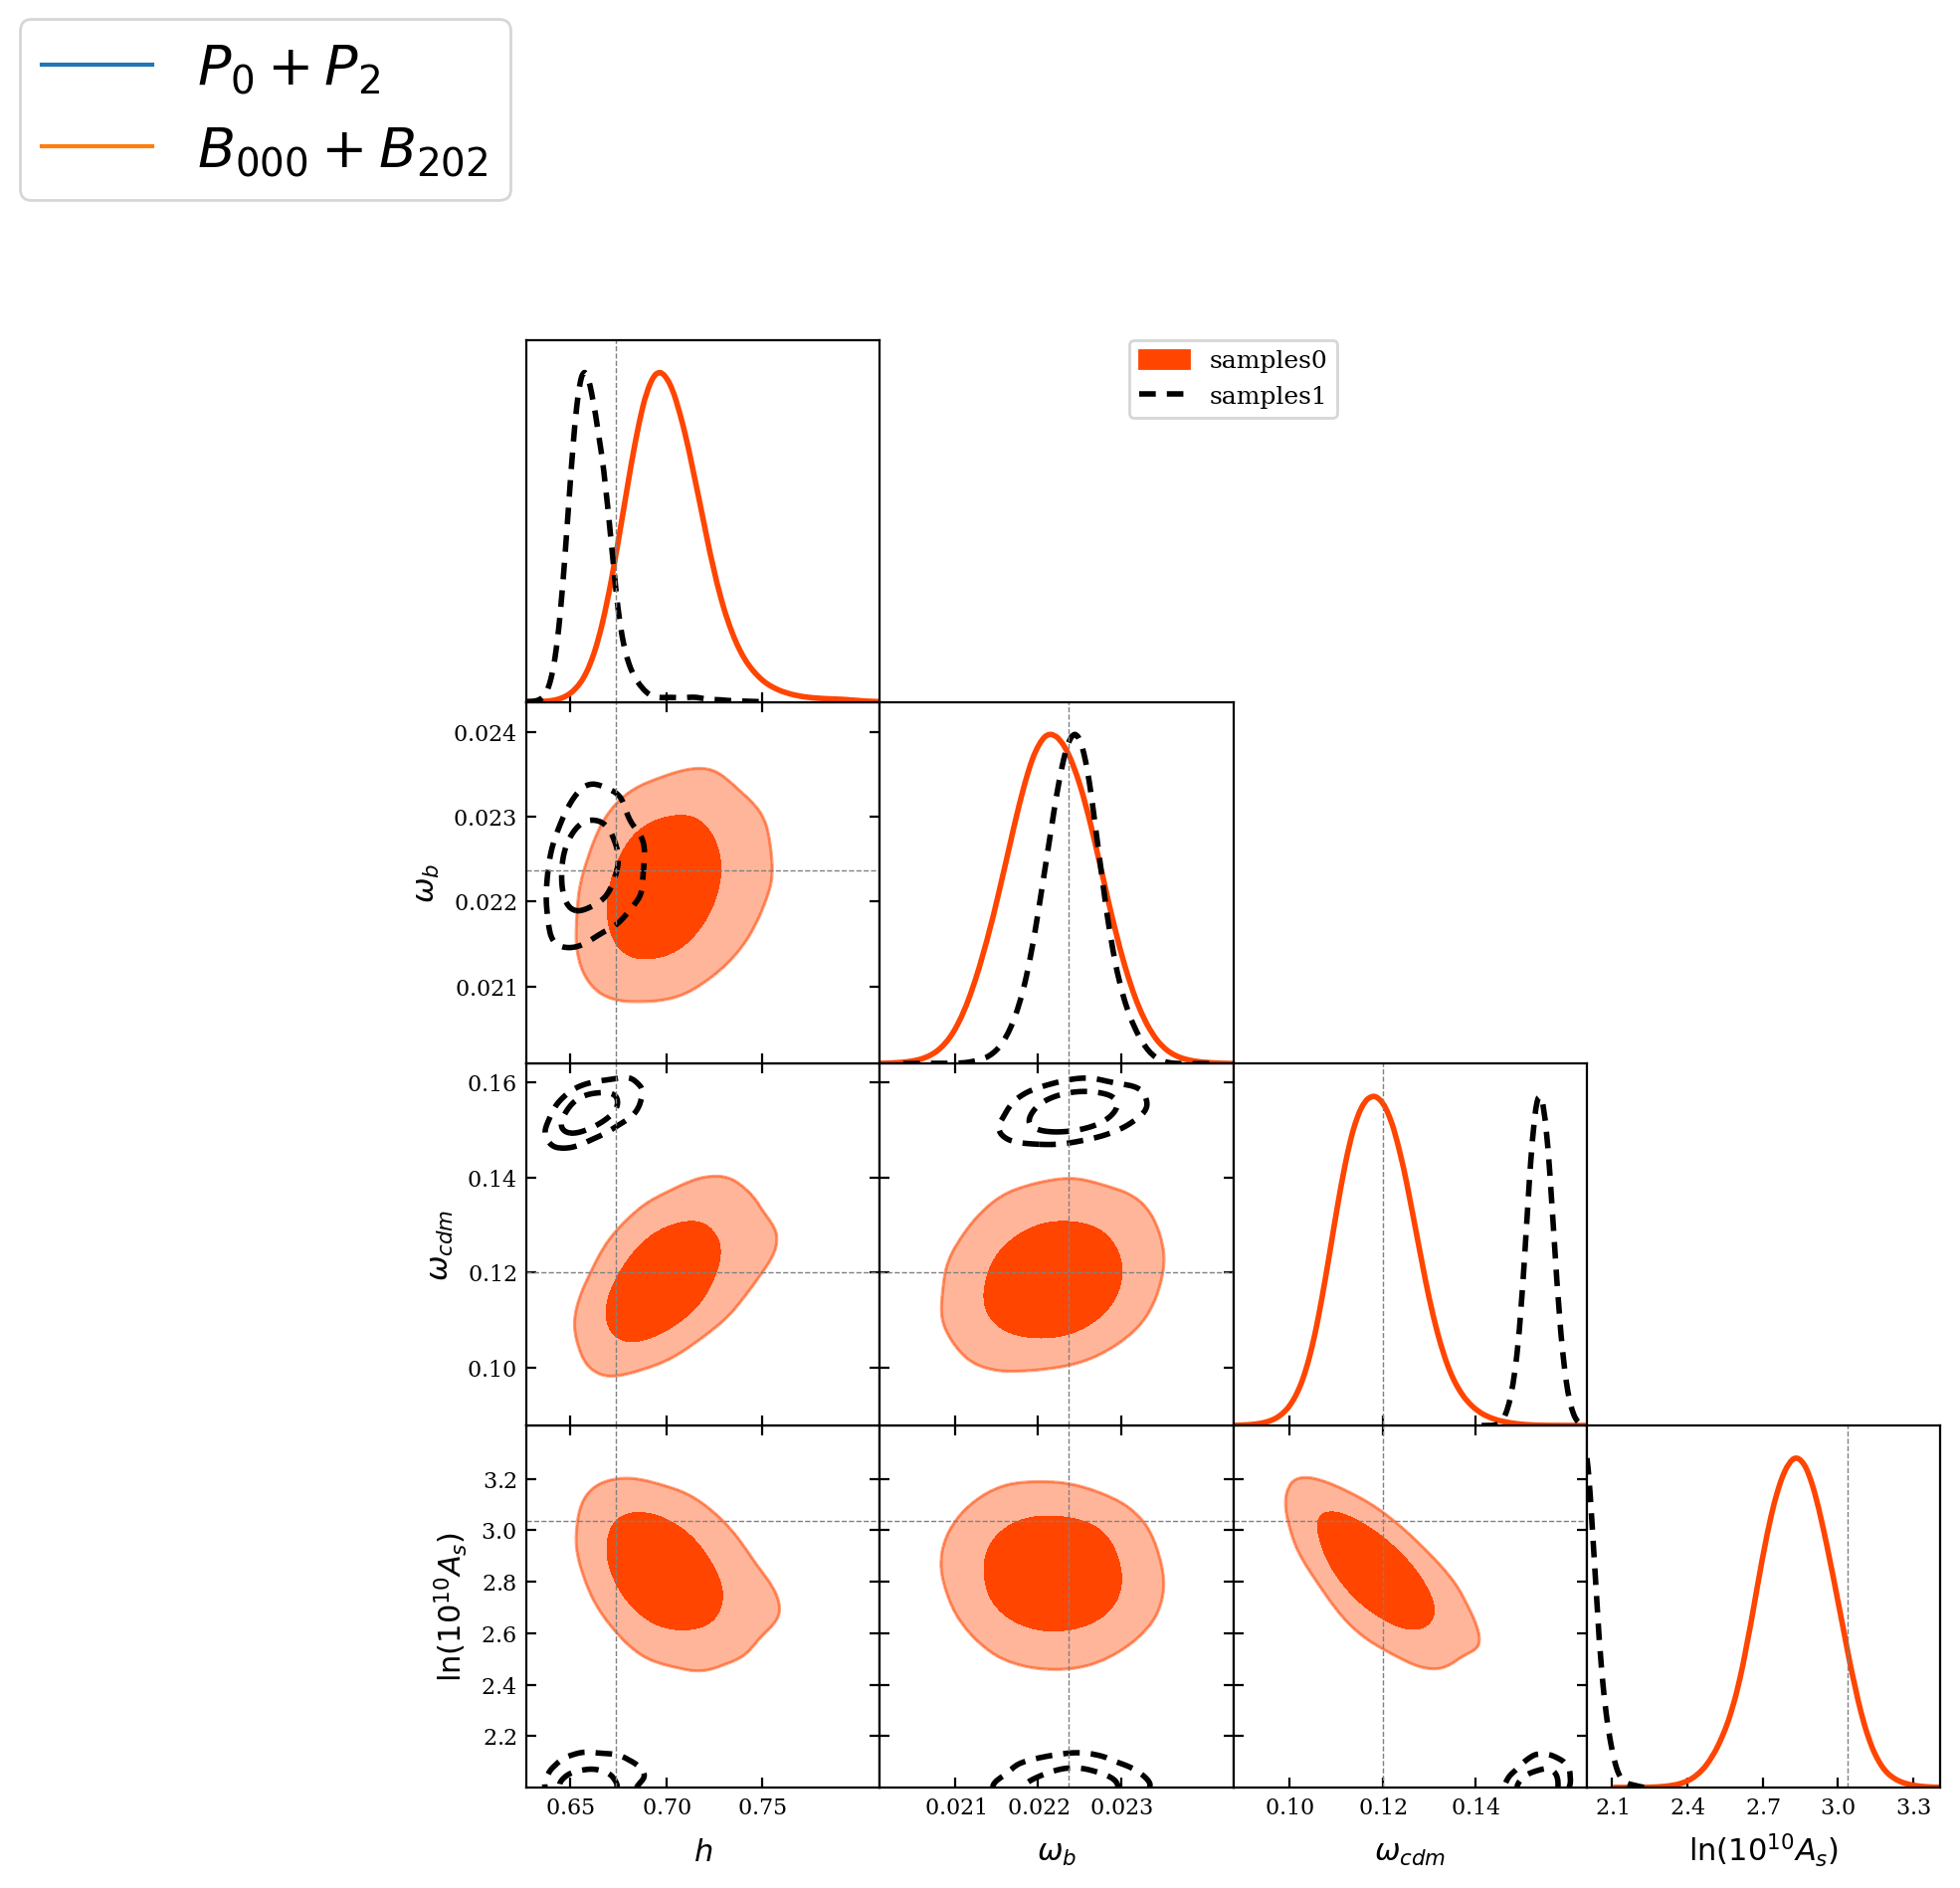

In [11]:
from desilike.samples import plotting
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'  #You can use 'monospace', 'Times New Roman', etc.
plt.rcParams['legend.fontsize'] = 50
# plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"
# import matplotlib.pyplot as plt
planck_truths = {
    'h': 0.6736,
    'omega_cdm': 0.12,
    'omega_b': 0.02237,
    'logA': np.log(10**10 * 2.0830e-9)  # log(10^10 A_s), or set to your matching definition
}
plotting.line_labels =False
plotting.plot_triangle([chain,chain2], params=['h','omega_b','omega_cdm','logA'],filled=[True,False],lw=[1,50],contour_colors=['orangered','black'],contour_ls=['-','--'],contour_lws=2,line_args=[{'color': 'orangered','ls':'-'},{'color': 'black','ls':'--','lw':2}],markers=planck_truths)
# plotting.plot_triangle([chain], params=['h','omega_b','omega_c','logA'],filled=[True],lw=[1],contour_colors=['black'],contour_ls=['-'],contour_lws=2,line_args=[{'color': 'black','ls':'--','lw':2}])


plotting.add_legend(labels=['$P_0+P_2 $','$B_{000}+B_{202}$'],bbox_to_anchor=(0.1,1.2),fontsize=20,frameon=True)
#fig.export('Hexadecapole.png')

#plotting.plot_triangle([chain], params=['qpar', 'qper'],labels=['$P_0+P_2+P_4$'],filled=True,smooth_scale_2d=0.1)
#plt.title('LRG 0.8-1.1')
# plotting.savefig('comparison.pdf')
#fig.add_text('LRG in 0.8<z<1.1')

Removed no burn in
[000016.95] [0/1] 08-12 15:36  Plotting                  INFO     Saving figure to fsy1_test.pdf.


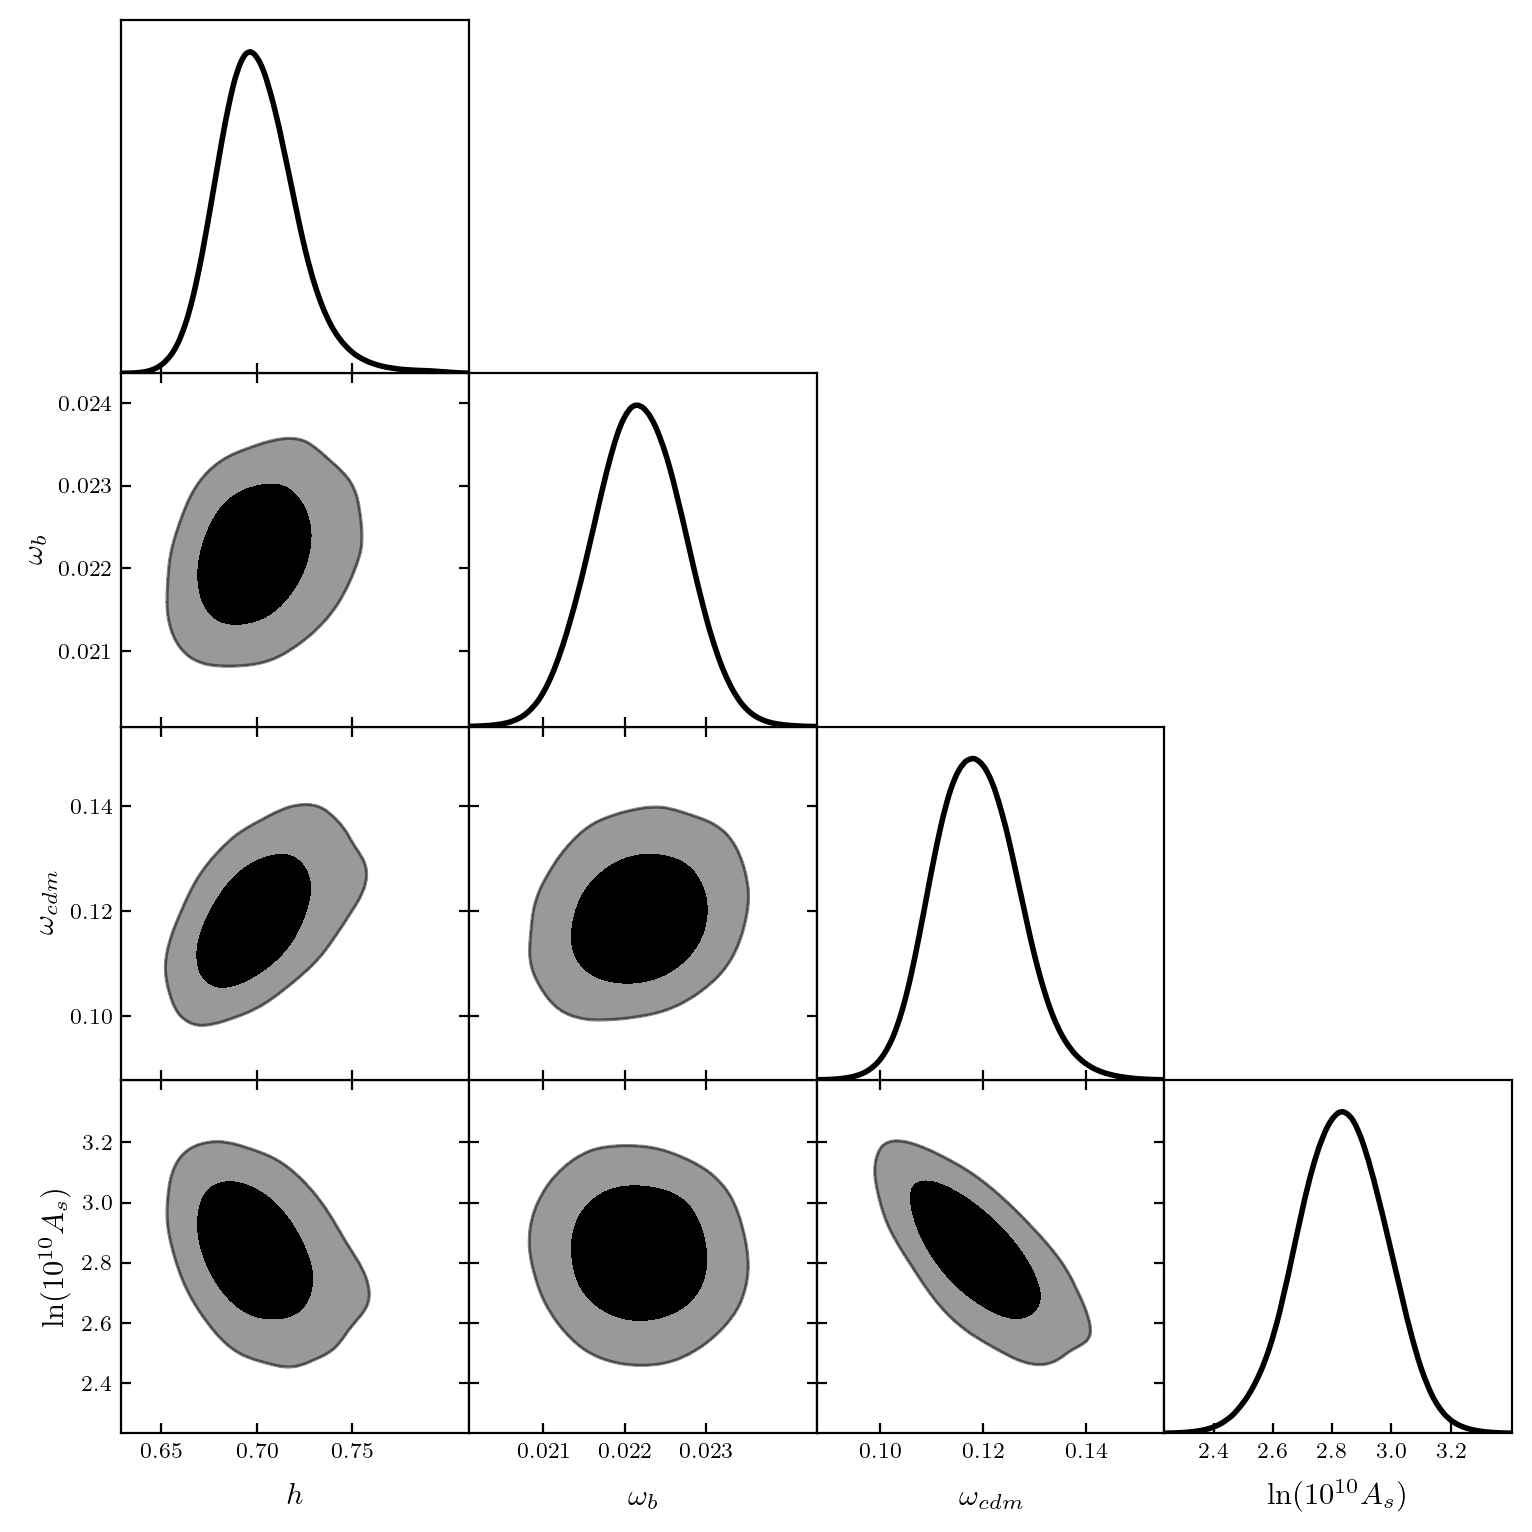

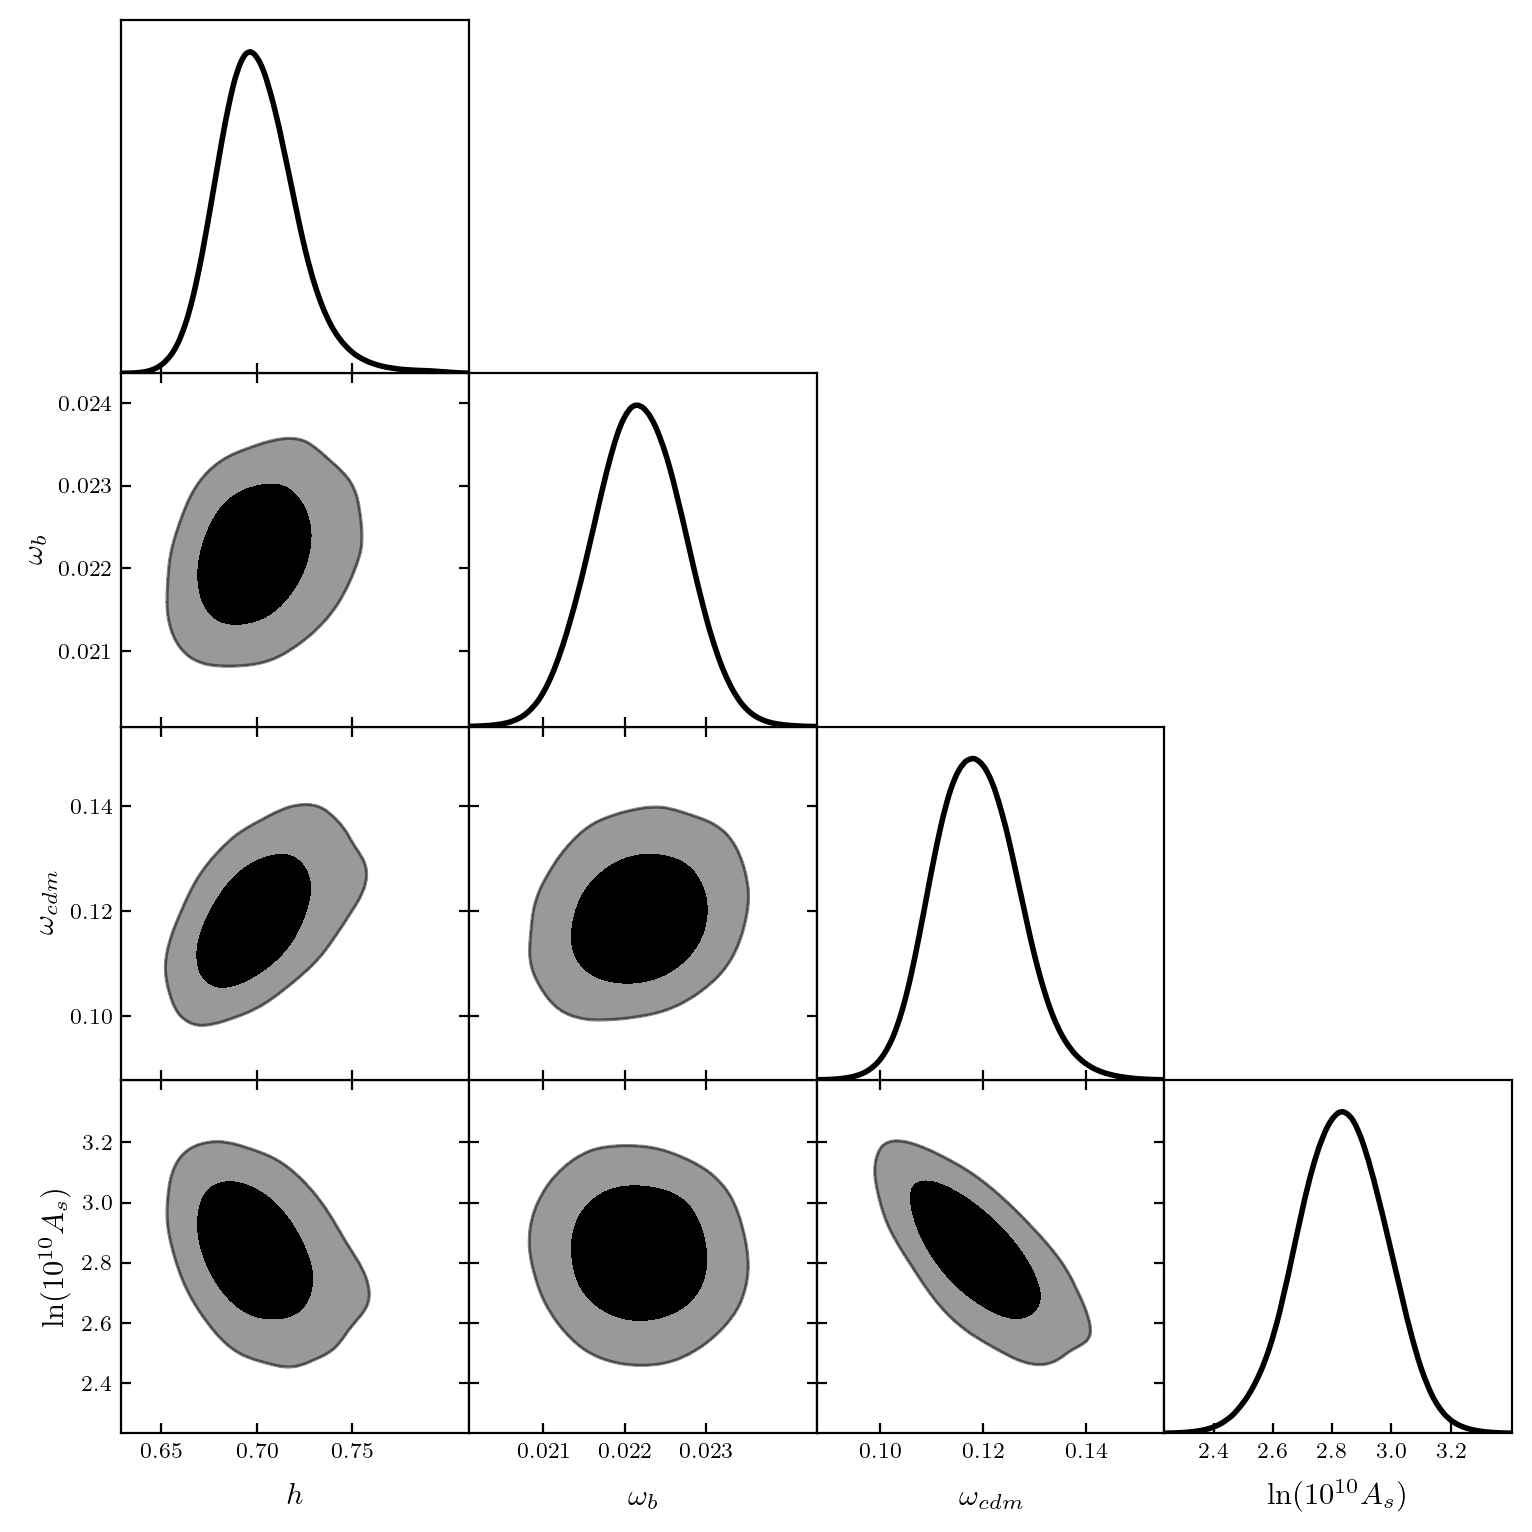

In [22]:
planck_truths = {
    'h': 0.674,
    'Omega_m': 0.315,
    'logA': 3.044  # log(10^10 A_s), or set to your matching definition
}

# Triangle plot with Planck 2018 markers
plotting.plot_triangle(
    [chain],
    params=['h', 'omega_b','omega_cdm', 'logA'],
    filled=[True],
    lw=[1],
    contour_colors=['black'],
    contour_ls=['-'],
    contour_lws=2,
    line_args=[{'color': 'black', 'ls': '--', 'lw': 2}],
)
plotting.savefig("fsy1_test.pdf")

In [6]:
data=np.load('/global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_folpsv2.npy',allow_pickle=True)

In [3]:
import h5py

filename = "/global/cfs/cdirs/desicollab/users/isaacmgm/Abacus_2ndGen_Fits/folpsDBaccoemu/chains/c_FolpsEFT_LRG_z0.800_Pkmax-0.201_bsfree.h5"
with h5py.File(filename, "r") as f:
    print(list(f.keys()))  # Shows top-level datasets/groups
    print(list(f['mcmc'].keys()))
    # Example: if chains are stored under 'samples'
    

['mcmc']
['accepted', 'blobs', 'chain', 'log_prob']


In [4]:
import emcee
import numpy as np

backend = emcee.backends.HDFBackend(filename, read_only=True)

# Get total chain shape: (nwalkers, nsteps, ndim)
chain_shape = backend.get_chain().shape
nwalkers, nsteps, ndim = chain_shape

# Set burn-in as 30% of total steps
burnin = int(0.5 * nsteps)

# Get flat chain, discarding burn-in
samples = backend.get_chain(discard=burnin, flat=True)  # shape: (n_samples, ndim)

# Select first 4 params and downsample by 10 for plotting speed
samples_subset = samples[:, :7][::10]

Removed no burn in


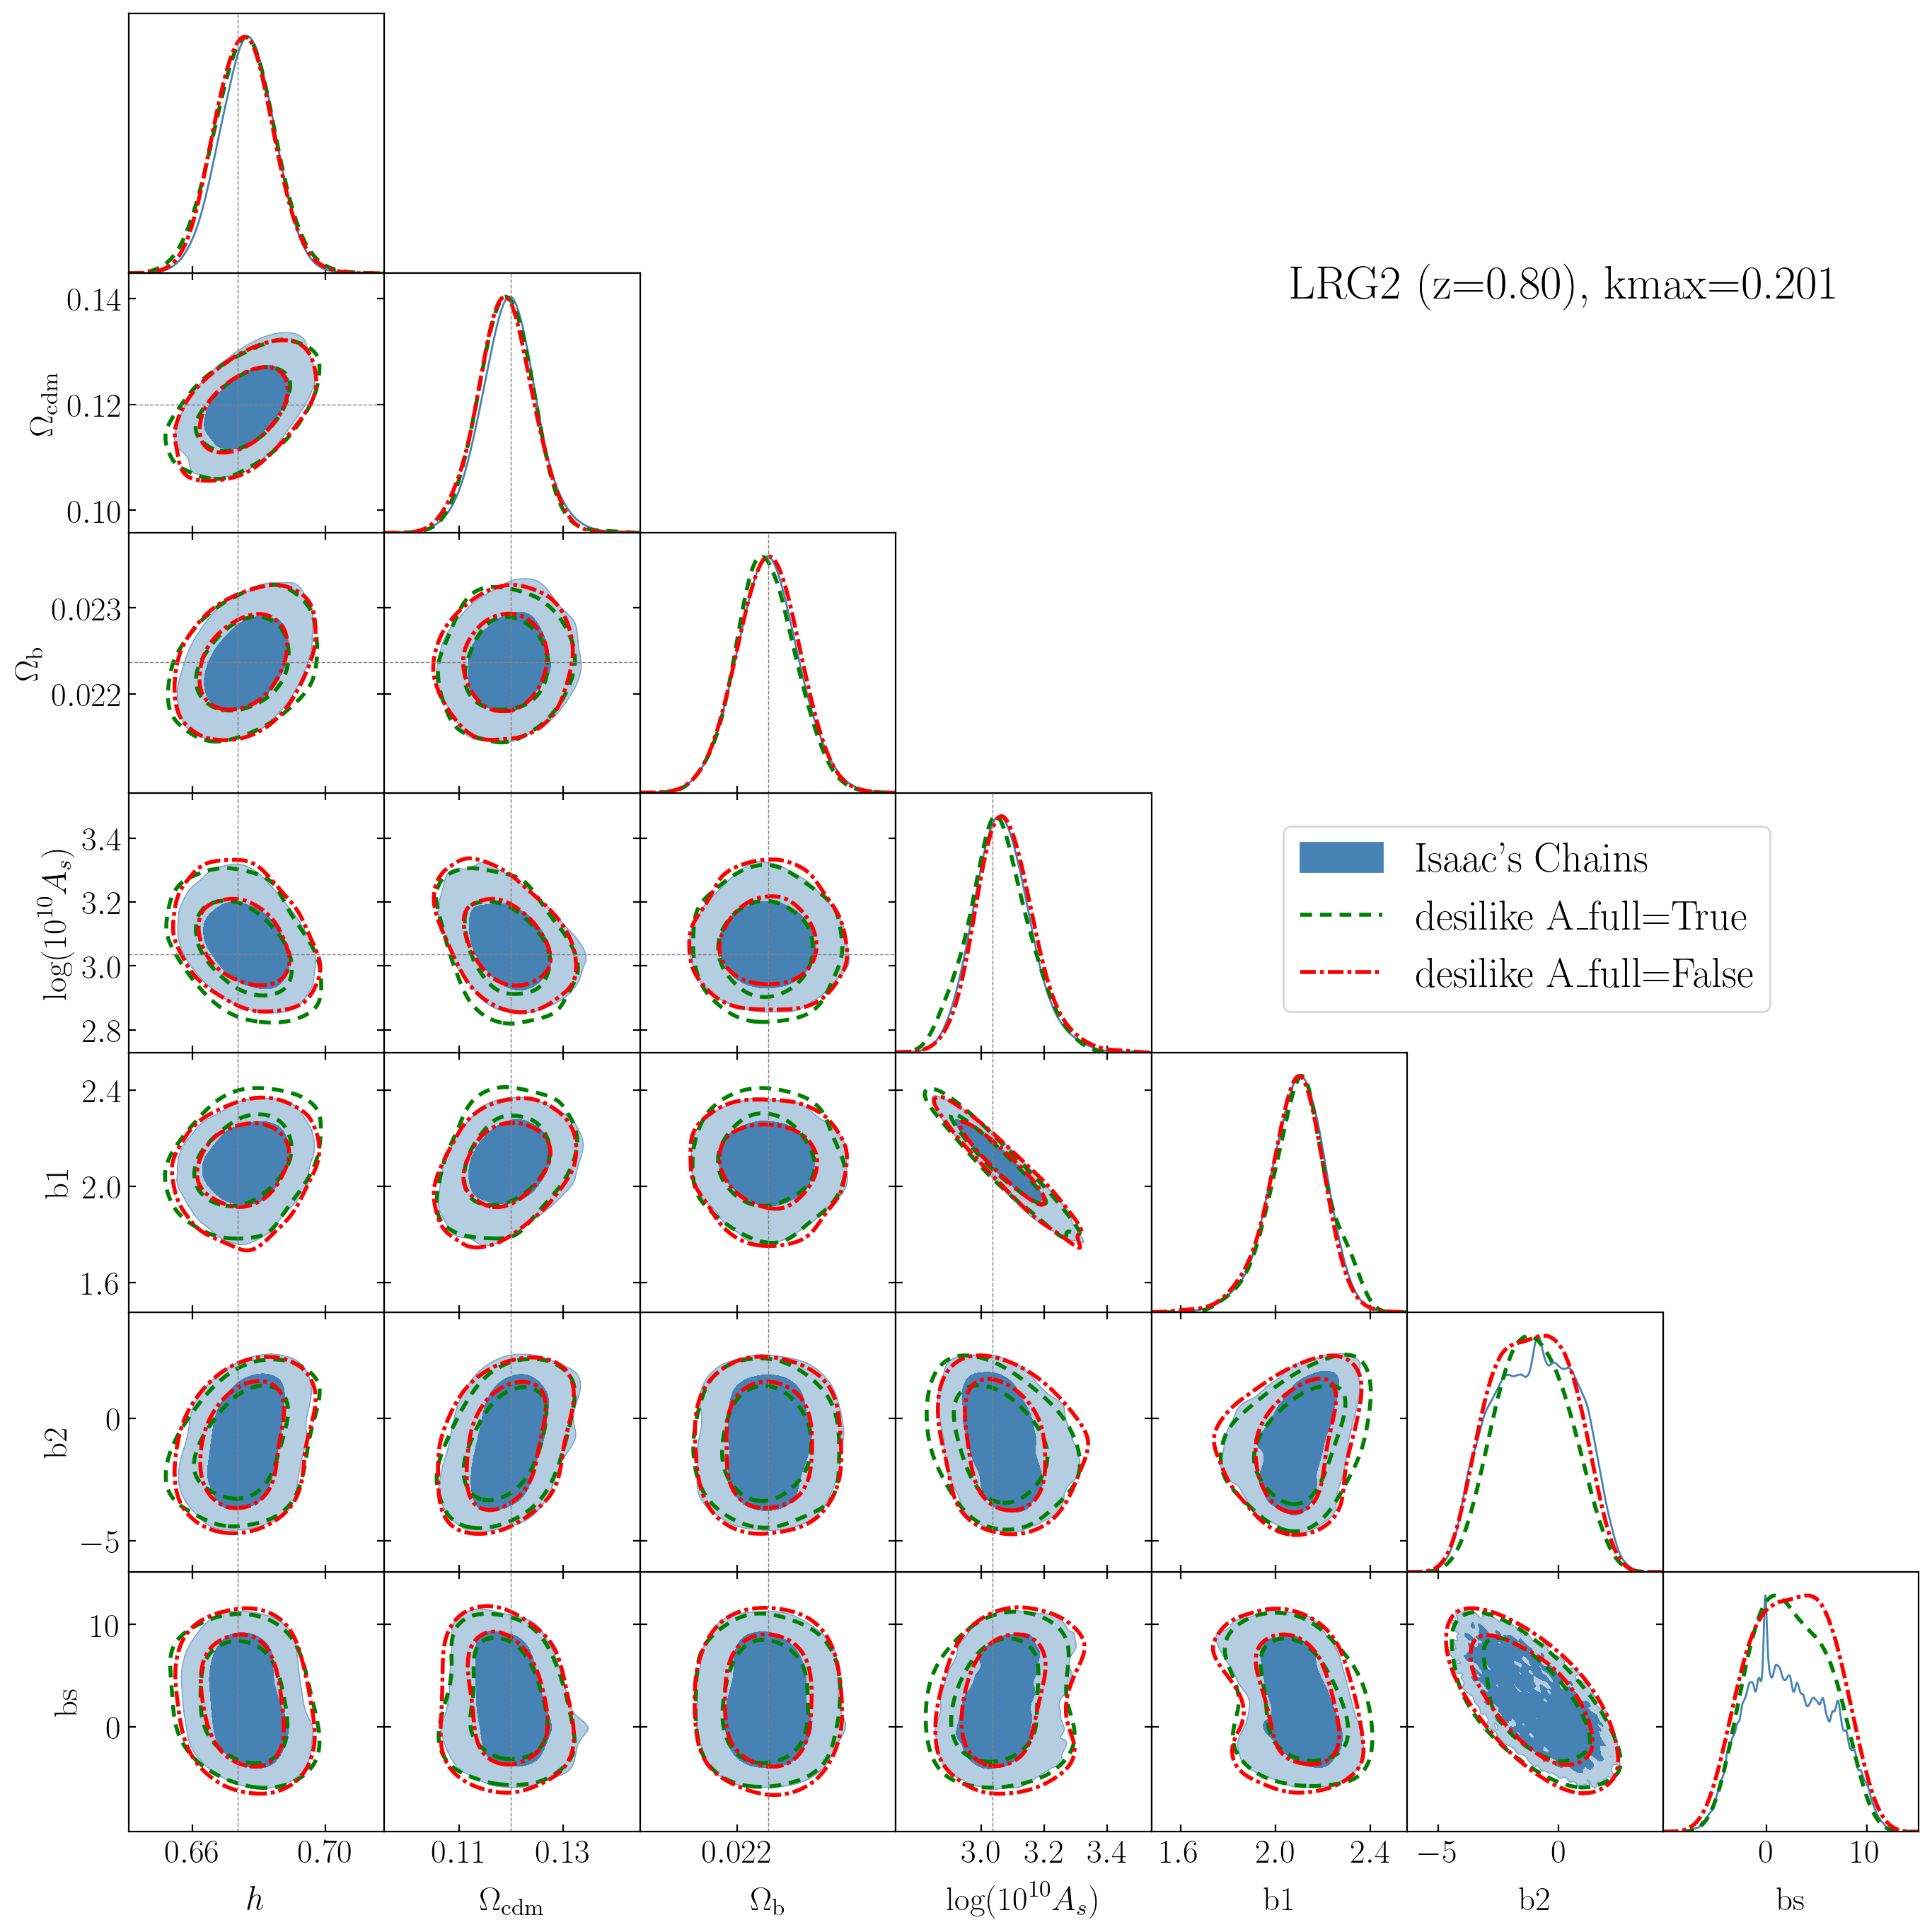

In [42]:
from getdist import MCSamples, plots
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# abacus_cosmo = {r'$h$':0.6736,
#            r'$\omega_{cdm}$':0.12,
#            r'$\omega_b$':0.02237, 
#            r'$\Omega_m$': 0.31519184934729094,
#            r'$\ln(10^{10}A_s)$': np.log(10**10 * 2.0830e-9),
#            r'$\sigma_8$':0.811355}

planck_truths = {
    'h': 0.6736,
    'omega_cdm': 0.12,
    'omega_b': 0.02237,
    'logA': np.log(10**10 * 2.0830e-9)  # log(10^10 A_s), or set to your matching definition
}
# High-resolution Retina output (for notebooks)


# Use LaTeX for all matplotlib text rendering
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 18

param_names = ['h', 'omega_cdm', 'omega_b', 'logA','b1','b2','bs']
param_labels = [r'$h$', r'$\Omega_{\rm cdm}$', r'$\Omega_{\rm b}$', r'$\log(10^{10}A_s)$']

gdsamples = MCSamples(samples=samples_subset, names=param_names, labels=param_labels)

g = plots.get_subplot_plotter()

# Increase axis font sizes
g.settings.axes_fontsize = 20
g.settings.lab_fontsize = 20

g.settings.line_labels = False

legend_labels = ['Chain 1', 'Chain 2']

# g.triangle_plot(
#     [gdsamples,samples2],
#     params=param_names,
#     filled=[False, True],  # First is dotted, second is filled
#     line_args=[{'lw':2,'ls': '--', 'color': 'black'}, {'lw': 1.2, 'color': 'steelblue'}],
#     contour_colors=['black', 'steelblue'],
#     contour_ls=['--', '-'], 
#     contour_lws=[2,1],
#     markers = planck_truths# Make contours dotted for both chains
# )
# g.add_legend(legend_labels=[r"Isaac's Chains","Desilike Implementation"],bbox_to_anchor=(0.1, 4.95),fontsize=24)
# g.add_text("LRG2 (z=0.80), kmax=0.201",x=0.7, y=5.95,fontsize=24)

g.triangle_plot(
    [gdsamples,samples2,samples3],
    params=param_names,
    filled=[True, False, False],  # First is dotted, second is filled
    line_args=[{'lw': 1.2, 'color': 'steelblue'},{'lw': 2,'ls': '--', 'color': 'green'},{'lw': 2,'ls': '-.', 'color': 'red'}],
    contour_colors=['steelblue', 'green','red'],
    contour_ls=['-','--', '-.'], 
    contour_lws=[1,2,2],
    markers = planck_truths# Make contours dotted for both chains
)

g.add_legend(legend_labels=[r"Isaac's Chains","desilike A_full=True","desilike A_full=False"],bbox_to_anchor=(0.5, 3.95),fontsize=24)
g.add_text("LRG2 (z=0.80), kmax=0.201",x=0.7, y=5.95,fontsize=24)

# g.add_legend(legend_labels=[r"$P_0+P_2$ (kmax=0.201)",r"$B_{000}+B_{202}$ (kmax=0.2,0.14)"],bbox_to_anchor=(0.5, 3.95),fontsize=18)
# plt.legend(fontsize=16, frameon=True)
g.export("PS_test5.png")



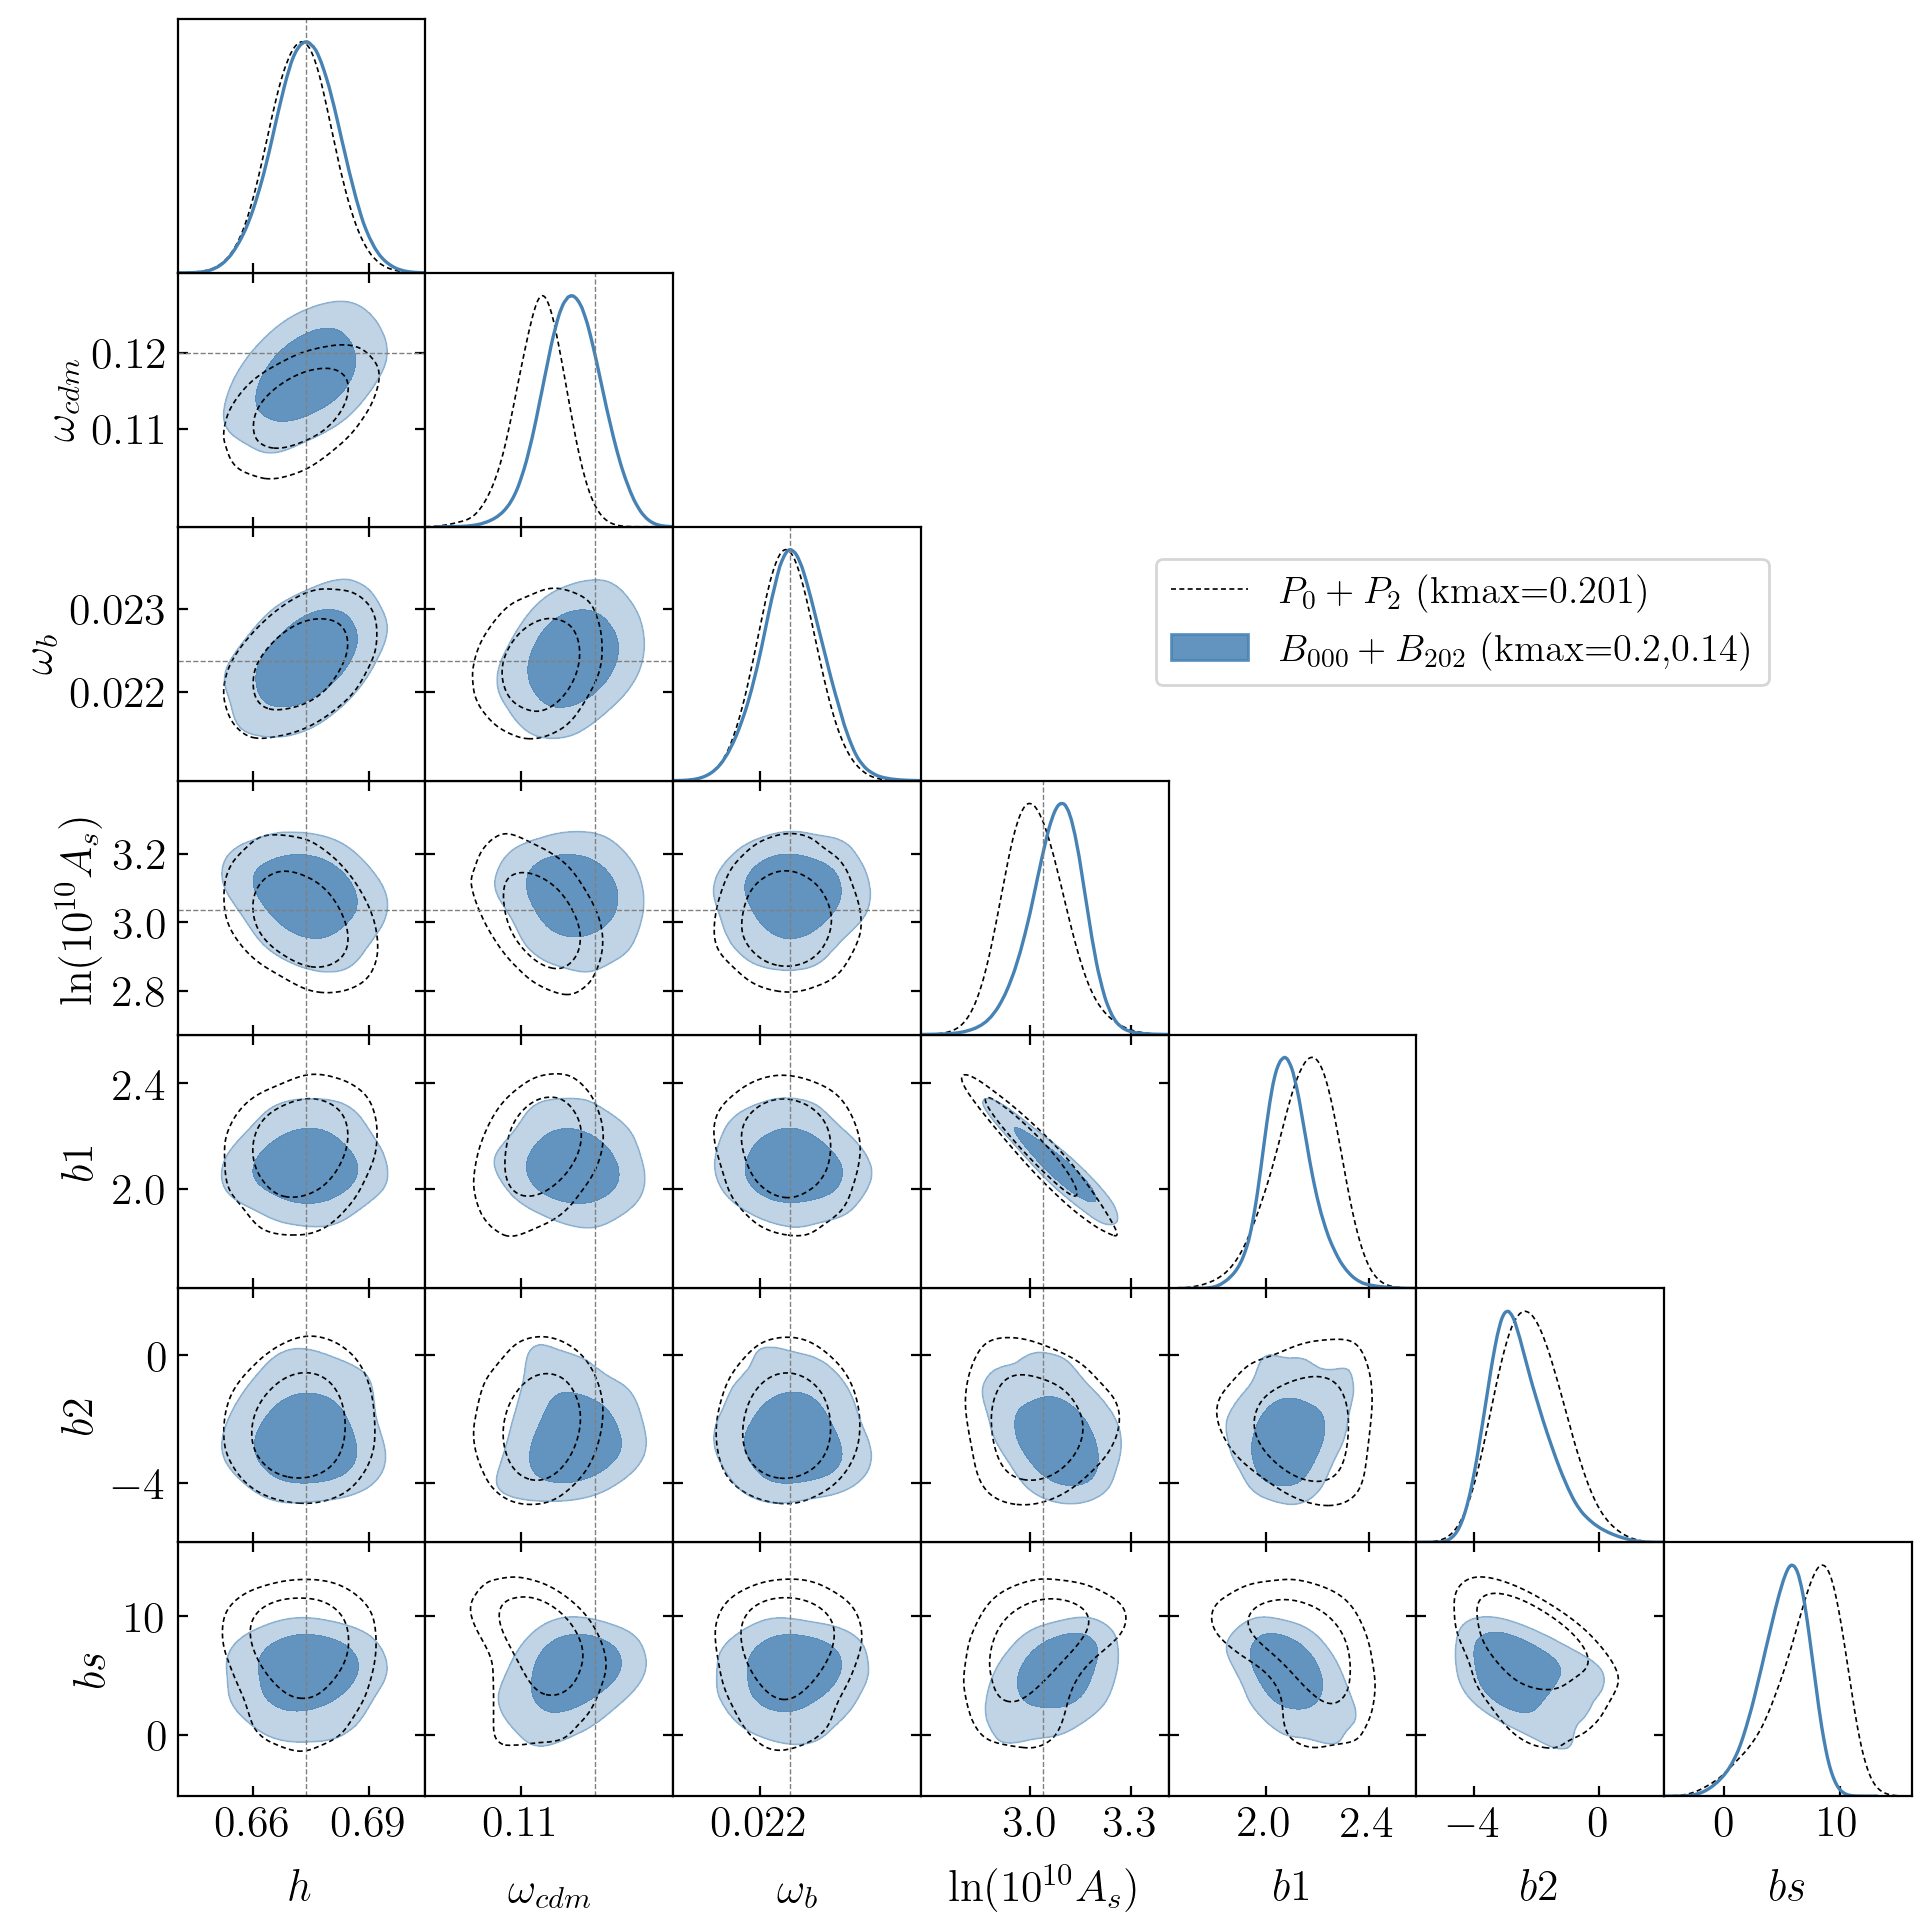

In [25]:
from getdist import MCSamples, plots
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# abacus_cosmo = {r'$h$':0.6736,
#            r'$\omega_{cdm}$':0.12,
#            r'$\omega_b$':0.02237, 
#            r'$\Omega_m$': 0.31519184934729094,
#            r'$\ln(10^{10}A_s)$': np.log(10**10 * 2.0830e-9),
#            r'$\sigma_8$':0.811355}

planck_truths = {
    'h': 0.6736,
    'omega_cdm': 0.12,
    'omega_b': 0.02237,
    'logA': np.log(10**10 * 2.0830e-9)  # log(10^10 A_s), or set to your matching definition
}
# High-resolution Retina output (for notebooks)


# Use LaTeX for all matplotlib text rendering
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 18

param_names = ['h', 'omega_cdm', 'omega_b', 'logA', 'b1','b2','bs']
param_labels = [r'$h$', r'$\Omega_{\rm cdm}$', r'$\Omega_{\rm b}$', r'$\log(10^{10}A_s)$']

# gdsamples = MCSamples(samples=samples_subset, names=param_names, labels=param_labels)

g = plots.get_subplot_plotter(width_inch=10)

# Increase axis font sizes
g.settings.axes_fontsize = 20
g.settings.lab_fontsize = 20

g.settings.line_labels = False

legend_labels = ['Chain 1', 'Chain 2']

g.triangle_plot(
    [samples2, samples3],
    params=param_names,
    filled=[False, True],  # First is dotted, second is filled
    line_args=[{'ls': '--', 'color': 'black'}, {'lw': 1.2, 'color': 'steelblue'}],
    contour_colors=['black', 'steelblue'],
    contour_ls=['--', '-'], 
    markers = planck_truths# Make contours dotted for both chains
)
# g.add_legend(legend_labels=[r"FolpsEFT_LRG_z0.800_Pkmax-0.201_bsfree","desilike FOLPSv2 kmax=0.201 standard bias"],bbox_to_anchor=(0.5, 3.95),fontsize=18)
g.add_legend(legend_labels=[r"$P_0+P_2$ (kmax=0.201)",r"$B_{000}+B_{202}$ (kmax=0.2,0.14)"],bbox_to_anchor=(0.5, 4.95),fontsize=18)
# plt.legend(fontsize=16, frameon=True)
# g.export("bispectrum_test2_Xfog.png")

In [18]:
p=samples2.paramNames

In [20]:
p.omega_b

AttributeError: 'ParamNames' object has no attribute 'omega_b'